## Figure 2 - Behavioral performance across experience

This script generates Figure 2, showing behavior metrics
across experience levels (Familiar, Novel, Novel+) including d-prime, hit rate,
response latency, running speed, pupil width, and lick rate.

In [140]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

import visual_behavior.utilities as vbu
import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [141]:
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_2')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

palette = utils.get_experience_level_colors()
experience_levels = utils.get_new_experience_levels()
cell_types = utils.get_cell_types()

## Data Loading

### Metadata tables

In [142]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
platform_behavior_sessions = pd.read_csv(os.path.join(loading.get_platform_analysis_cache_dir(), 'platform_behavior_sessions_table.csv'), index_col=0)
platform_ophys_behavior_sessions = pd.read_csv(os.path.join(loading.get_platform_analysis_cache_dir(), 'platform_ophys_behavior_sessions_table.csv'), index_col=0)

# save to more convenient name
behavior_sessions = platform_behavior_sessions.copy()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
palette = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

In [143]:
print(len(behavior_sessions.mouse_id.unique()), 'mice')
print(len(behavior_sessions.index.unique()), 'behavior sessions')


66 mice
2942 behavior sessions


In [144]:
print(len(platform_ophys_behavior_sessions.mouse_id.unique()), 'mice')
print(len(platform_ophys_behavior_sessions.ophys_experiment_id.unique()), 'experiments')
print(len(platform_ophys_behavior_sessions.ophys_session_id.unique()), 'ophys sessions')
print(len(platform_ophys_behavior_sessions.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


### Multi-session dataframes for behavior variables

In [145]:
# # Set params
# interpolate = False
# output_sampling_rate = 30
# inclusion_criteria = 'platform_experiment_table'

# # Running speed
# event_type = 'all'
# data_type = 'running_speed'
# conditions = ['ophys_experiment_id', 'is_change']
# running_speed_mdf = loading.get_multi_session_df_for_conditions(data_type, event_type, conditions, inclusion_criteria,
#                                                                interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                epoch_duration_mins=None)
# running_speed_mdf_changes = running_speed_mdf[running_speed_mdf.is_change == True]
# running_speed_mdf_changes = running_speed_mdf_changes.drop_duplicates(subset='behavior_session_id')

# # Running speed - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# running_speed_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                                        interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                        epoch_duration_mins=5)
# running_speed_mdf_changes_epochs = running_speed_mdf_epochs[running_speed_mdf_epochs.is_change == True]
# running_speed_mdf_images_epochs = running_speed_mdf_epochs[running_speed_mdf_epochs.is_change == False]

# # Pupil width
# data_type = 'pupil_width'
# conditions = ['ophys_experiment_id', 'is_change']
# full_pupil_mdf = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions, inclusion_criteria,
#                                                             interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                             epoch_duration_mins=None)
# pupil_mdf = full_pupil_mdf[full_pupil_mdf.is_change == True]
# pupil_mdf = pupil_mdf.drop_duplicates(subset='behavior_session_id')
# pupil_mdf = pupil_mdf[pupil_mdf.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# # Pupil width - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# pupil_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                               interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                               epoch_duration_mins=5)
# pupil_mdf_changes_epochs = pupil_mdf_epochs[pupil_mdf_epochs.is_change == True]

# # Lick rate
# data_type = 'lick_rate'
# conditions = ['ophys_experiment_id', 'is_change']
# lick_rate_mdf = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions, inclusion_criteria,
#                                                            interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                            epoch_duration_mins=None)
# lick_rate_mdf = lick_rate_mdf[lick_rate_mdf.is_change == True]
# lick_rate_mdf = lick_rate_mdf.drop_duplicates(subset='behavior_session_id')
# lick_rate_mdf = lick_rate_mdf[lick_rate_mdf.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# # Lick rate - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# lick_rate_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                                   interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                   epoch_duration_mins=5)
# lick_rate_mdf_changes_epochs = lick_rate_mdf_epochs[lick_rate_mdf_epochs.is_change == True]
# lick_rate_mdf_images_epochs = lick_rate_mdf_epochs[lick_rate_mdf_epochs.is_change == False]

### Behavior metrics

In [ ]:
behavior_metrics_dir = loading.get_performance_metrics_dir()

# Behavior metrics computed by AllenSDK
behavior_stats_sdk = pd.read_hdf(os.path.join(behavior_metrics_dir, 'sdk_all_sessions.h5'), key='data')
behavior_stats_sdk.index.name = 'behavior_session_id'
columns = ['mouse_id', 'cre_line', 'cell_type', 'experience_level', 'session_type', 'behavior_session_id']
behavior_stats_sdk = behavior_stats_sdk.merge(behavior_sessions.reset_index()[columns], on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
behavior_stats_sdk = behavior_stats_sdk[behavior_stats_sdk.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
behavior_stats_sdk['mouse_id'] = [int(mouse_id) for mouse_id in behavior_stats_sdk.mouse_id.values]

# Behavior metrics computed on a flash by flash basis, limited to engaged portions of session
engaged_behavior_stats_stim = pd.read_hdf(os.path.join(loading.get_platform_analysis_cache_dir(), 'stimulus_based_engaged_only_all_sessions.h5'), key='data')
engaged_behavior_stats_stim = engaged_behavior_stats_stim.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
engaged_behavior_stats_stim = engaged_behavior_stats_stim[engaged_behavior_stats_stim.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]


# Behavior metrics computed on a flash by flash basis, limited to engaged portions of session
behavior_stats_stim = pd.read_hdf(os.path.join(behavior_metrics_dir, 'stimulus_based_all_sessions.h5'), key='data')
behavior_stats_stim = behavior_stats_stim.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
behavior_stats_stim = behavior_stats_stim[behavior_stats_stim.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]


# Load platform behavior stats for stimulus-based metrics
# produced with loading.get_behavior_stats_from_stimulus_presentations()
platform_behavior_stats = pd.read_csv(os.path.join(behavior_metrics_dir,  'platform_behavior_stats_engaged.csv'), index_col=0)
platform_behavior_stats = platform_behavior_stats.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
platform_behavior_stats = platform_behavior_stats[platform_behavior_stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]


In [147]:
print(len(behavior_stats_sdk.mouse_id.unique()), 'mice')
print(len(behavior_stats_sdk.index.unique()), 'behavior sessions')


66 mice
202 behavior sessions


In [148]:
print(len(engaged_behavior_stats_stim.mouse_id.unique()), 'mice')
print(len(engaged_behavior_stats_stim.ophys_experiment_id.unique()), 'experiments')
print(len(engaged_behavior_stats_stim.ophys_session_id.unique()), 'ophys sessions')
print(len(engaged_behavior_stats_stim.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


In [149]:
print(len(behavior_stats_stim.mouse_id.unique()), 'mice')
print(len(behavior_stats_stim.ophys_experiment_id.unique()), 'experiments')
print(len(behavior_stats_stim.ophys_session_id.unique()), 'ophys sessions')
print(len(behavior_stats_stim.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


## Plotting

### Panel A: Lick raster for Familiar/Novel/Novel+ comparison
Select example mouse with data at all experience levels

In [115]:
mouse_id = 425496

# Get datasets for each experience level
familiar_experiment_id = platform_experiments[(platform_experiments.mouse_id == mouse_id) &
                                             (platform_experiments.experience_level == 'Familiar')].index.values[0]
familiar_dataset = loading.get_ophys_dataset(familiar_experiment_id)

novel_experiment_id = platform_experiments[(platform_experiments.experience_level == 'Novel') &
                                         (platform_experiments.mouse_id == mouse_id)].index.values[0]
novel_dataset = loading.get_ophys_dataset(novel_experiment_id)

novel_plus_experiment_id = platform_experiments[(platform_experiments.experience_level == 'Novel +') &
                                              (platform_experiments.mouse_id == mouse_id)].index.values[0]
novel_plus_dataset = loading.get_ophys_dataset(novel_plus_experiment_id)


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

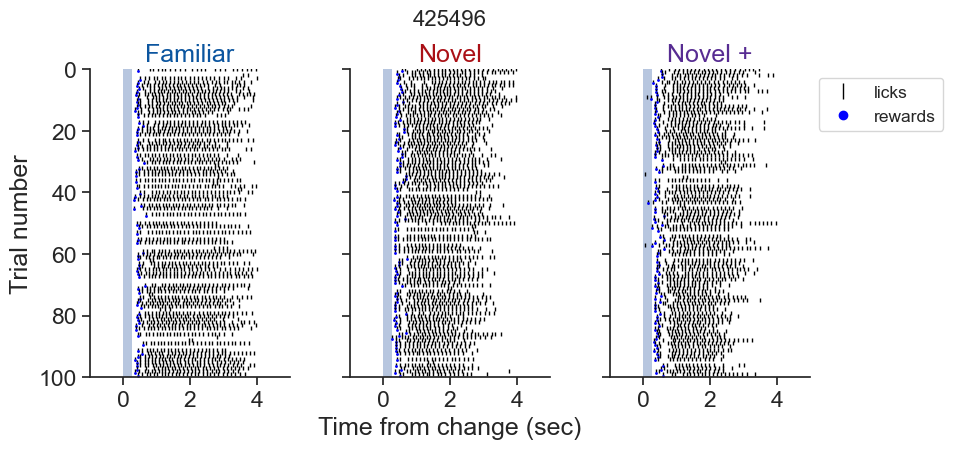

In [116]:

# Plot lick rasters for F/N/N+
colors = utils.get_experience_level_colors()
figsize = (12, 4)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)

trials = familiar_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[0] = ppf.plot_lick_raster_for_trials(trials, title='Familiar', ax=ax[0])
ax[0].set_title('Familiar', color=colors[0])
ax[0].set_xlabel('')

trials = novel_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[1] = ppf.plot_lick_raster_for_trials(trials, title='Novel', ax=ax[1])
ax[1].set_title('Novel', color=colors[1])
ax[1].set_ylabel('')

trials = novel_plus_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[2] = ppf.plot_lick_raster_for_trials(trials, title='Novel +', legend=True, ax=ax[2])
ax[2].set_title('Novel +', color=colors[2])
ax[2].set_ylabel('')
ax[2].set_xlabel('')

plt.subplots_adjust(wspace=0.3)
plt.suptitle(mouse_id, x=0.6, y=1.03, fontsize=16)
utils.save_figure(fig, figsize, save_dir, 'lick_rasters', str(mouse_id) + '_F_N_N+_example_fig')

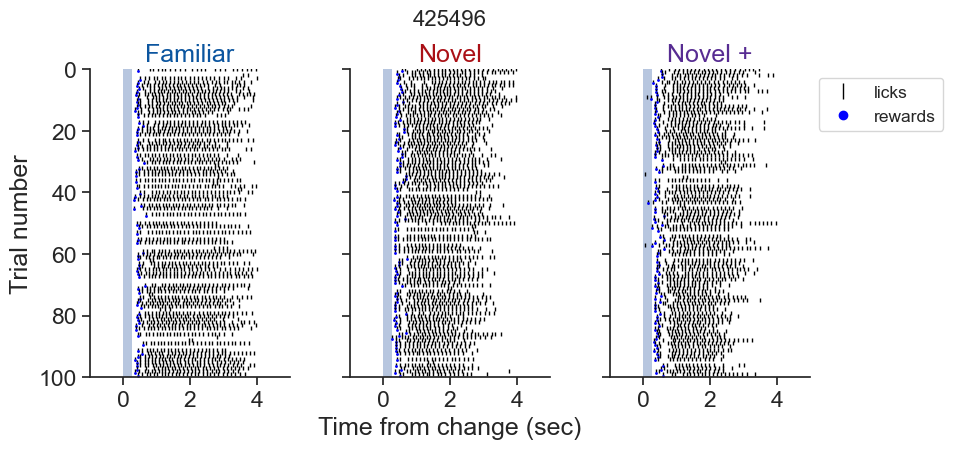

In [117]:

# Plot lick rasters for F/N/N+
colors = utils.get_experience_level_colors()
figsize = (12, 4)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)

trials = familiar_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[0] = ppf.plot_lick_raster_for_trials(trials, title='Familiar', ax=ax[0])
ax[0].set_title('Familiar', color=colors[0])
ax[0].set_xlabel('')

trials = novel_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[1] = ppf.plot_lick_raster_for_trials(trials, title='Novel', ax=ax[1])
ax[1].set_title('Novel', color=colors[1])
ax[1].set_ylabel('')

trials = novel_plus_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[2] = ppf.plot_lick_raster_for_trials(trials, title='Novel +', legend=True, ax=ax[2])
ax[2].set_title('Novel +', color=colors[2])
ax[2].set_ylabel('')
ax[2].set_xlabel('')

plt.subplots_adjust(wspace=0.3)
plt.suptitle(mouse_id, x=0.6, y=1.03, fontsize=16)
utils.save_figure(fig, figsize, save_dir, 'lick_rasters', str(mouse_id) + '_F_N_N+_example_fig')

### Behavior performance

In [185]:
#### Load stimulus_response_df for all sessions and compute performance metrics on a flash wise basis. 

saving_stats


<Axes: ylabel='Max d-prime'>

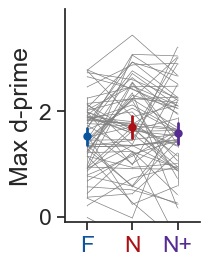

In [182]:
metric = 'max_dprime'
stats = behavior_stats_sdk.copy()

ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel='Max d-prime', ylims=[-0.1, 3.5],
                                      best_image=False, show_mice=True, plot_stats=True,
                                      stripplot=False, show_ns=False, 
                                      save_dir=save_dir, folder='behavior_metrics', ax=None)

saving_stats


<Axes: ylabel='Response latency (s)'>

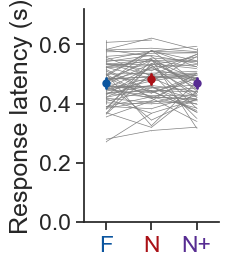

In [119]:
metric = 'response_latency_mean'
stats = behavior_stats_stim.copy()

ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel='Response latency (s)', 
                                    ylims=None, show_mice=True, plot_stats=True, stripplot=False, show_ns=False,
                                      save_dir=save_dir, folder='behavior_metrics', ax=None)

### Event aligned behavior

#### Load dataframes for running, pupil, and licks, for both changes & omissions

In [ ]:
#### Multi-session dataframes for behavior variables

epoch_duration_mins = None

# Running speed
running_speed_mdf_changes = loading.get_behavior_multi_session_df('running_speed', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)

# Pupil width
pupil_mdf_changes = loading.get_behavior_multi_session_df('pupil_width', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
there are 1880 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

...

removing 1 problematic experiments
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_lick_rate_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_lick_rate_all_is_change_platform_experiment_table.pkl
there are 1602 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


<Axes: ylabel='Lick rate (Hz)'>

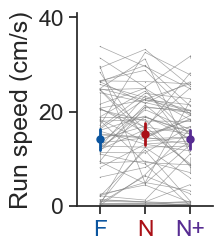

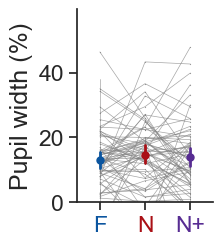

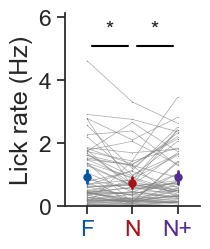

In [ ]:
title = ''
#### Running 

#### Changes

df = running_speed_mdf_changes.copy()
df['expts'] = 'all'

ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'running_speed', 
                                            ylabel='Run speed (cm/s)', ylims=None, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='',ax=None)


#### Pupil 

#### Changes

df = pupil_mdf_changes.copy()
df['expts'] = 'all'
ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'pupil_width', 
                                            ylabel='Pupil width (%)', ylims=None, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title=title, ax=None)




### Within session changes in behavior

##### Rolling d-prime using false alarm rate across stimulus presentations

In [150]:
import visual_behavior.utilities as utilities

In [ ]:
# mouse_id = platform_experiments.mouse_id.unique()[0]
file_dir = loading.get_stimulus_behavior_response_dir()
stim_behavior_response_df = pd.DataFrame()
problem_mice = []
for mouse_id in platform_experiments.mouse_id.unique(): 
    filename = str(mouse_id)+'_stimulus_behavior_response_df.csv'
    filepath = os.path.join(file_dir, filename)
    try: 
        df = pd.read_csv(filepath, index_col=0)
        df['mouse_id'] = mouse_id
        stim_behavior_response_df = pd.concat((stim_behavior_response_df, df))
    except:
        problem_mice.append(mouse_id)
print(len(stim_behavior_response_df.mouse_id.unique()))
print(problem_mice)

66
[]


In [152]:
stim_behavior_response_df.head()

,stimulus_presentations_id,start_time,relative_time,epoch,is_change,omitted,post_omitted,image_name,mean_running_speed,mean_pupil_width,response_latency,lick_latency,reward_rate,licked,behavior_session_id,mouse_id
0,1,307.176084,0.00000,0,False,False,False,im065,12.685861,1.066955,0.595966,0.595966,1.885254,True,794968300,412036
1,2,307.926674,0.75059,0,False,False,False,im065,12.339447,1.063985,0.012176,0.012176,1.885254,True,794968300,412036
2,3,308.677274,1.50119,0,False,False,False,im065,26.097918,1.051677,NaN,NaN,1.885254,False,794968300,412036
3,4,309.427924,2.25184,0,False,False,False,im065,30.444546,1.027226,NaN,NaN,1.885254,False,794968300,412036
4,5,310.178494,3.00241,0,False,False,False,im065,28.378029,1.029168,NaN,NaN,1.885254,False,794968300,412036


In [153]:
rolling_sdf = utilities.get_stimulus_based_rolling_performance_df_for_dataset(stim_behavior_response_df,
                                                          session_key='behavior_session_id')

# Merge with metadata 
rolling_sdf = rolling_sdf.join(platform_experiments[['behavior_session_id', 'experience_level', 'cell_type']].set_index('behavior_session_id'), on='behavior_session_id', how='left', rsuffix='_exp')

KeyError: 'could_change'

In [126]:
rolling_sdf.head()

,stimulus_presentations_id,start_time,time_in_session,is_change,licked,hit_rate_raw,hit_rate,false_alarm_rate_raw,false_alarm_rate,rolling_dprime,n_go_opportunities,n_catch_opportunities,reward_rate,behavior_session_id,experience_level,cell_type
6,7,311.917547,0.00000,True,0.0,0.000000,0.500000,NaN,NaN,NaN,1.0,0.0,inf,794071128,Familiar,Excitatory
20,21,322.426137,10.50859,True,0.0,0.000000,0.250000,NaN,NaN,NaN,2.0,0.0,inf,794071128,Familiar,Excitatory
33,34,332.184097,20.26655,True,1.0,0.333333,0.333333,NaN,NaN,NaN,3.0,0.0,inf,794071128,Familiar,Excitatory
43,44,339.690217,27.77267,True,1.0,0.500000,0.500000,NaN,NaN,NaN,4.0,0.0,inf,794071128,Familiar,Excitatory
59,60,351.699987,39.78244,True,0.0,0.400000,0.400000,NaN,NaN,NaN,5.0,0.0,1.485776,794071128,Familiar,Excitatory


In [127]:
rolling_sdf.columns

Index(['stimulus_presentations_id', 'start_time', 'time_in_session',
       'is_change', 'licked', 'hit_rate_raw', 'hit_rate',
       'false_alarm_rate_raw', 'false_alarm_rate', 'rolling_dprime',
       'n_go_opportunities', 'n_catch_opportunities', 'reward_rate',
       'behavior_session_id', 'experience_level', 'cell_type'],
      dtype='object')

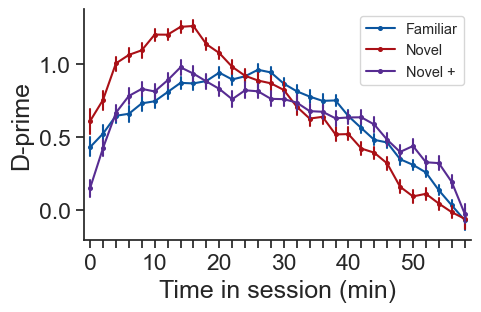

In [156]:
# rolling d-prime over time in session, in 2 min bins, x labeled in 10 min increments
ax = ppf.plot_rolling_metric_over_time_in_session(
    rolling_sdf, metric='rolling_dprime',
    bin_size_seconds=120, max_minutes=60, label_every=5,
    ylabel="D-prime", save_dir=save_dir, folder='within_session_behavior',
)

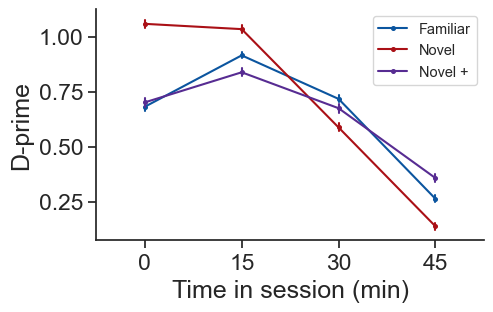

In [162]:
# rolling d-prime over time in session, in 2 min bins, x labeled in 10 min increments
ax = ppf.plot_rolling_metric_over_time_in_session(
    rolling_sdf, metric='rolling_dprime',
    bin_size_seconds=60*15, max_minutes=60, label_every=1,
    ylabel="D-prime", save_dir=save_dir, folder='within_session_behavior',
)

##### Mean d-prime in 15-minute bins, distribution across mice by experience level

`ppf.plot_metric_in_time_bins_by_experience` supports `plot_type='boxplot'` (boxes across mice + gray per-mouse lines) or `plot_type='pointplot'` (mean ± CI across mice, connected across time bins).

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_94965/3957574894.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['%d-%d' % (int(b), int(b) + bin_size_min) for b in bin_order])


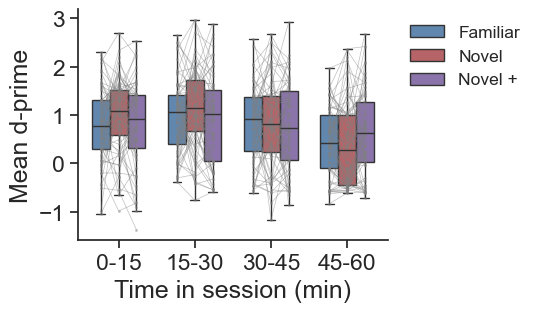

In [171]:
# Mean d-prime in 15-min bins, distribution ACROSS MICE per experience level (boxplot + per-mouse lines).
# rolling_sdf was only joined with experience_level / cell_type, so bring in mouse_id for the
# across-mice aggregation the function does internally.
rolling_sdf_mouse = rolling_sdf.merge(
    platform_experiments[['behavior_session_id', 'mouse_id']].drop_duplicates(),
    on='behavior_session_id', how='left')

ax = ppf.plot_metric_in_time_bins_by_experience(
    rolling_sdf_mouse, metric='rolling_dprime', bin_size_minutes=15, max_minutes=60,
    plot_type='boxplot', ylabel='D-prime', save_dir=save_dir)


In [175]:
rolling_sdf_mouse = rolling_sdf.merge(
    platform_experiments[['behavior_session_id', 'mouse_id']].drop_duplicates(),
    on='behavior_session_id', how='left')

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2843: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xlabel('Time in session (min)')


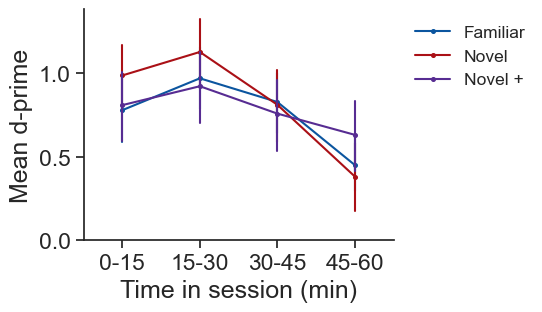

In [180]:
# Same data, plotted as a pointplot: mean +/- CI across mice, connected across time bins
ax = ppf.plot_metric_in_time_bins_by_experience(
    rolling_sdf_mouse, metric='rolling_dprime', bin_size_minutes=15, max_minutes=60,
    plot_type='pointplot', ylabel='Mean d-prime', save_dir=save_dir)


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2842: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['%d-%d' % (int(b), int(b) + bin_size_minutes) for b in bin_order])


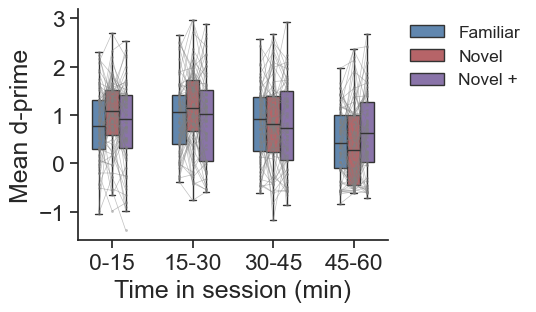

In [179]:
# Same data, plotted as a pointplot: mean +/- CI across mice, connected across time bins
ax = ppf.plot_metric_in_time_bins_by_experience(
    rolling_sdf_mouse, metric='rolling_dprime', bin_size_minutes=15, max_minutes=60,
    plot_type='boxplot', ylabel='Mean d-prime', save_dir=save_dir)


##### Rolling d-prime by cohort

VisualBehavior
VisualBehaviorTask1B
VisualBehaviorMultiscope


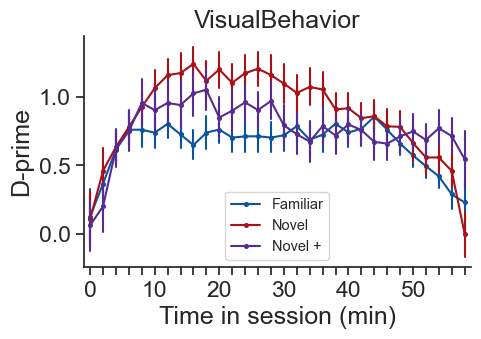

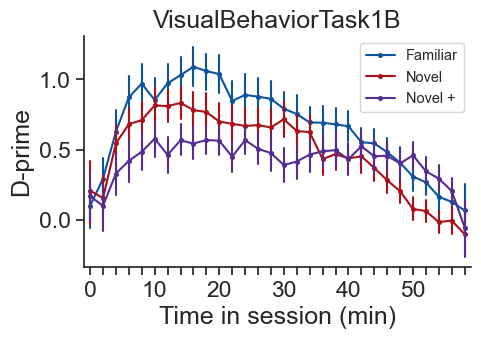

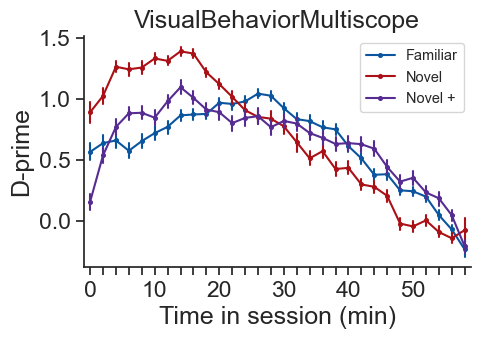

In [129]:

for project_code in platform_experiments.project_code.unique():
    print(project_code)
    behavior_session_ids = platform_experiments[platform_experiments.project_code == project_code].behavior_session_id.unique()
    project_df = rolling_sdf[rolling_sdf.behavior_session_id.isin(behavior_session_ids)]
    # rolling d-prime over time in session, in 2 min bins, x labeled in 10 min increments
    ppf.plot_rolling_metric_over_time_in_session(
        project_df, metric='rolling_dprime', title=project_code,
        bin_size_seconds=120, max_minutes=60, label_every=5,
        ylabel="D-prime", save_dir=save_dir, suffix='_'+project_code, ax=None)

##### Pupil diameter in first 2 mins of session

##### New version of stim behavior response df

In [130]:
# mouse_id = platform_experiments.mouse_id.unique()[0]
file_dir = loading.get_stimulus_behavior_response_dir()
stim_behavior_response_df = pd.DataFrame()
problem_mice = []
for mouse_id in platform_experiments.mouse_id.unique(): 
    filename = str(mouse_id)+'_stimulus_behavior_response_df.csv'
    filepath = os.path.join(file_dir, filename)
    try: 
        df = pd.read_csv(filepath, index_col=0)
        df['mouse_id'] = mouse_id
        stim_behavior_response_df = pd.concat((stim_behavior_response_df, df))
    except:
        problem_mice.append(mouse_id)

stim_behavior_response_df = stim_behavior_response_df.merge(platform_behavior_sessions[['experience_level']], on='behavior_session_id')
print(len(stim_behavior_response_df.mouse_id.unique()))
print(problem_mice)

66
[]


In [131]:
stim_behavior_response_df.head()

,stimulus_presentations_id,start_time,is_change,could_change,omitted,post_omitted,image_name,mean_running_speed,mean_pupil_width,lick_latency,licked,licks,reward_rate,auto_rewarded,is_image_novel,is_sham_change,epoch,behavior_session_id,mouse_id,experience_level
0,1,307.176084,False,False,False,False,im065,12.685861,NaN,0.595966,True,[307.77205],1.885254,NaN,False,False,0,794968300,412036,Familiar
1,2,307.926674,False,False,False,False,im065,12.339447,0.976615,0.012176,True,[307.93885],1.885254,NaN,False,False,0,794968300,412036,Familiar
2,3,308.677274,False,False,False,False,im065,26.097918,0.955810,NaN,False,[],1.885254,NaN,False,False,0,794968300,412036,Familiar
3,4,309.427924,False,False,False,False,im065,30.444546,0.951674,NaN,False,[],1.885254,NaN,False,False,0,794968300,412036,Familiar
4,5,310.178494,False,False,False,False,im065,28.378029,NaN,NaN,False,[],1.885254,NaN,False,False,0,794968300,412036,Familiar


66


<Axes: title={'center': 'Pupil width over first 2 minutes of session'}, xlabel='Time (sec)', ylabel='Pupil width (%)'>

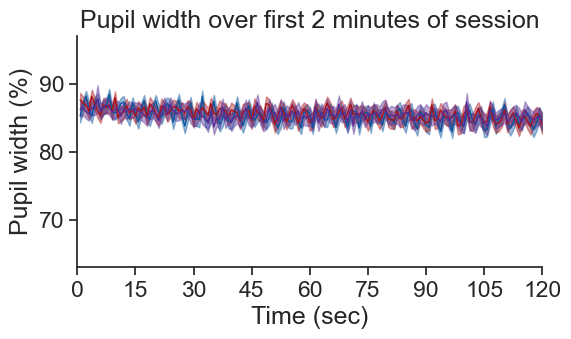

In [132]:
image_sdf = stim_behavior_response_df.reset_index()
image_sdf = image_sdf[image_sdf.is_change==False]
image_sdf = image_sdf[image_sdf.omitted==False]

# Convert to percentage of baseline                                                       
# image_sdf['mean_pupil_width'] = image_sdf['mean_pupil_width'] - 1
image_sdf['mean_pupil_width'] = image_sdf['mean_pupil_width'] * 100

# Calculate the relative stimulus_presentations_id
image_sdf['stimulus_number'] = image_sdf.groupby(['mouse_id', 'behavior_session_id']).cumcount() + 1

# Check that everything is there
print(len(image_sdf.mouse_id.unique()))

metric = 'mean_pupil_width'
ylabel = 'Pupil width (%)'
time_window_min = 2
ylim = (0, 20)
title = f'Pupil width over first {time_window_min} minutes of session'

ppf.plot_metric_across_stimuli_by_experience_level(image_sdf, metric, time_window_min=time_window_min, 
                                                title=title, ylabel=ylabel, ylim=None, 
                                                interval=20, ax=None, save_dir=save_dir, 
                                                folder='within_session_behavior')



##### Original version of stim behavior response df

In [133]:
# mouse_id = platform_experiments.mouse_id.unique()[0]
file_dir = loading.get_stimulus_behavior_response_dir()
stim_behavior_response_df = pd.DataFrame()
problem_mice = []
for mouse_id in platform_experiments.mouse_id.unique(): 
    filename = str(mouse_id)+'_behavior_across_stimuli_df.csv'
    filepath = os.path.join(file_dir, filename)
    try: 
        df = pd.read_csv(filepath, index_col=0)
        df['mouse_id'] = mouse_id
        stim_behavior_response_df = pd.concat((stim_behavior_response_df, df))
    except:
        problem_mice.append(mouse_id)
        
stim_behavior_response_df = stim_behavior_response_df.merge(platform_behavior_sessions[['experience_level']], on='behavior_session_id')
print(len(stim_behavior_response_df.mouse_id.unique()))
print(problem_mice)

66
[]


In [134]:
image_sdf = stim_behavior_response_df.reset_index()
image_sdf = image_sdf[image_sdf.is_change==False]
image_sdf = image_sdf[image_sdf.omitted==False]

# Convert to percentage of baseline                                                       
image_sdf['mean_pupil_width'] = image_sdf['mean_pupil_width'] - 1
image_sdf['mean_pupil_width'] = image_sdf['mean_pupil_width'] * 100

# Calculate the relative stimulus_presentations_id
image_sdf['stimulus_number'] = image_sdf.groupby(['mouse_id', 'behavior_session_id']).cumcount() + 1

# Check that everything is there
print(len(image_sdf.mouse_id.unique()))


66


<Axes: title={'center': 'Pupil width over first 2 minutes of session'}, xlabel='Time (sec)', ylabel='Pupil width (%)'>

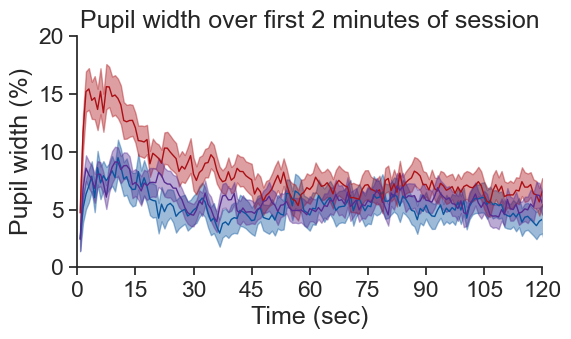

In [135]:

metric = 'mean_pupil_width'
ylabel = 'Pupil width (%)'
time_window_min = 2
ylim = (0, 20)
title = f'Pupil width over first {time_window_min} minutes of session'

ppf.plot_metric_across_stimuli_by_experience_level(image_sdf, metric, time_window_min=time_window_min, 
                                                title=title, ylabel=ylabel, ylim=ylim, 
                                                interval=20, ax=None, save_dir=save_dir, 
                                                folder='within_session_behavior')



### Response rate across conditions

In [154]:
platform_behavior_stats.head()

,trial_type,response_probability,behavior_session_id,fraction_engaged,dprime_non_change,dprime_could_change,ophys_session_id,ophys_container_id,mouse_id,indicator,...,stimulus_type,exp_level,engagement,behavior_stage,stimulus_experience_level,date,n_relative_to_first_novel,first_novel,second_novel_active,last_familiar_active
0,change,0.708333,794968300,0.947061,2.164678,0.945272,794918442.0,412036,412036,GCaMP6f,...,images,familiar_images,NaN,familiar_images_ophys,familiar_images,20181213,-1.0,False,False,True
1,non_change,0.053030,794968300,0.947061,2.164678,0.945272,794918442.0,412036,412036,GCaMP6f,...,images,familiar_images,NaN,familiar_images_ophys,familiar_images,20181213,-1.0,False,False,True
2,could_change,0.345776,794968300,0.947061,2.164678,0.945272,794918442.0,412036,412036,GCaMP6f,...,images,familiar_images,NaN,familiar_images_ophys,familiar_images,20181213,-1.0,False,False,True
3,omission,0.352941,794968300,0.947061,2.164678,0.945272,794918442.0,412036,412036,GCaMP6f,...,images,familiar_images,NaN,familiar_images_ophys,familiar_images,20181213,-1.0,False,False,True
4,post-omission,0.546218,794968300,0.947061,2.164678,0.945272,794918442.0,412036,412036,GCaMP6f,...,images,familiar_images,NaN,familiar_images_ophys,familiar_images,20181213,-1.0,False,False,True


In [155]:
platform_behavior_stats.columns

Index(['trial_type', 'response_probability', 'behavior_session_id',
       'fraction_engaged', 'dprime_non_change', 'dprime_could_change',
       'ophys_session_id', 'ophys_container_id', 'mouse_id', 'indicator',
       'full_genotype', 'driver_line', 'cre_line', 'reporter_line', 'sex',
       'age_in_days', 'imaging_plane_group_count', 'project_code',
       'session_type', 'session_number', 'image_set', 'behavior_type',
       'experience_level', 'prior_exposures_to_session_type',
       'prior_exposures_to_image_set', 'prior_exposures_to_omissions',
       'date_of_acquisition', 'equipment_name', 'num_depths_per_area',
       'ophys_experiment_id', 'num_targeted_structures', 'engaged_trial_count',
       'false_alarm_trial_count', 'trial_count', 'go_trial_count',
       'correct_reject_trial_count', 'catch_trial_count', 'file_id',
       'hit_trial_count', 'miss_trial_count', 'passive', 'cell_type',
       'training_stage', 'first_day_of_stage', 'last_day_of_stage',
       'has_ophy

In [136]:
data = platform_behavior_stats.copy()
print(len(data.mouse_id.unique()), 'mice')
print(len(data.behavior_session_id.unique()), 'sessions')

data = data[data.fraction_engaged>0.5]
print(len(data.mouse_id.unique()), 'mice')
print(len(data.behavior_session_id.unique()), 'sessions')


66 mice
200 sessions
64 mice
162 sessions


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:6835: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_ylim(ylims[0], ylims[1])


saving_stats


<Axes: ylabel='Response rate'>

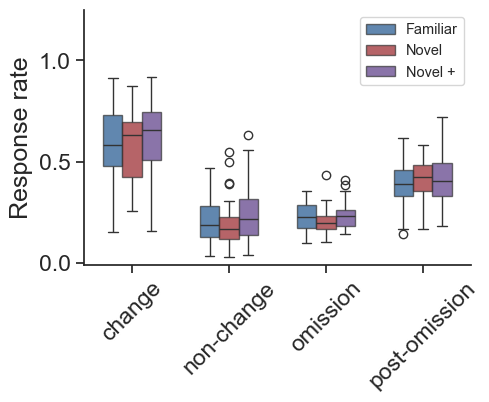

In [137]:

ppf.plot_response_rate_by_trial_type(platform_behavior_stats, metric='response_probability',
                                     fraction_engaged_thresh=0.7, ylabel='Response rate', ylims=(-0.01, 1),
                                     save_dir=save_dir, folder='behavior_metrics', ax=None)

## Composite figure

table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticks(ax.get_xticks().tolist())


table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2136: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticks(ax.get_xticks().tolist())
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:6840: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(title)
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_94965/1932294729.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_H.set_xticklabels([t.get_text().capitalize() for t in ax_H.get_xticklabels()], rotation=45)


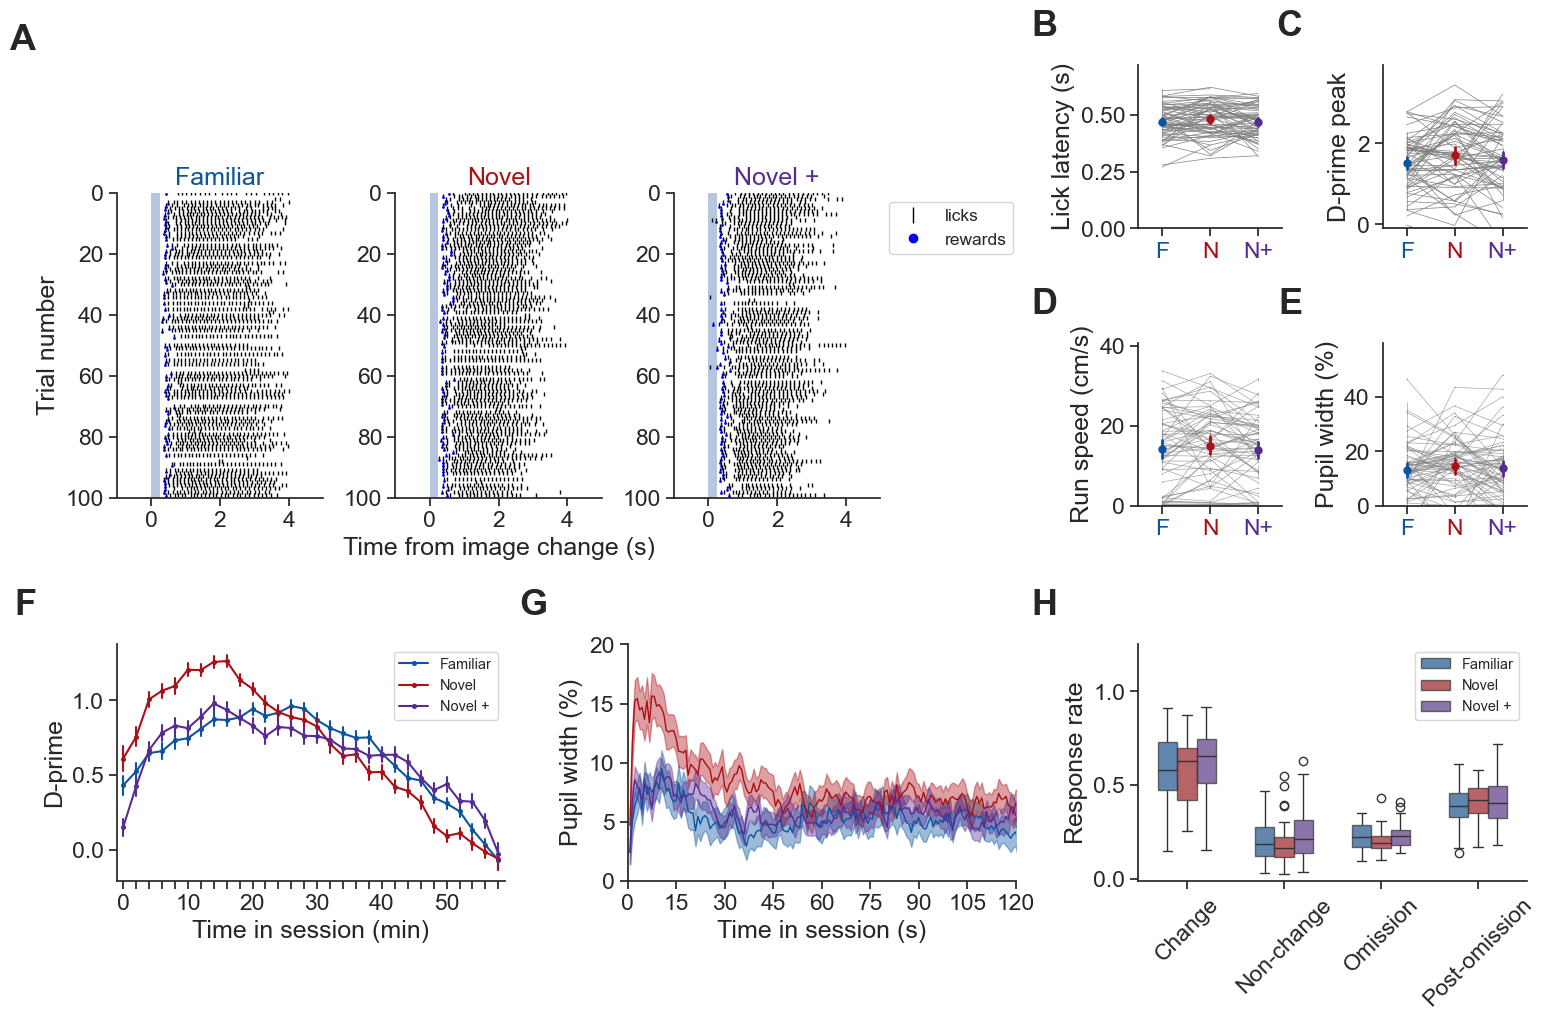

In [139]:
# Composite Figure 2
# NOTE: run the notebook top-to-bottom first so all dataframes / datasets below exist:
#   familiar_dataset, novel_dataset, novel_plus_dataset, behavior_stats_sdk,
#   behavior_stats_stim, running_speed_mdf_changes, pupil_mdf_changes,
#   rolling_sdf, image_sdf, platform_behavior_stats
# Layout mirrors slide 4 of "VBO figures - revised v4.pptx":
#   A (lick rasters, top-left) | B/C/D/E (2x2 metrics, top-right) | F/G/H (bottom row)

colors = utils.get_experience_level_colors()

figsize = (25, 10)
fig = plt.figure(figsize=figsize)

def panel_label(ax, label, dx=-58, dy=16):
    # offset (in points) from the axis top-left corner. dx is negative enough to clear the
    # y-tick labels and ylabel; dy lifts the letter above the axis. Tracks the axis if it moves.
    ax.annotate(label, xy=(0, 1), xycoords='axes fraction',
                xytext=(dx, dy), textcoords='offset points',
                fontsize=26, fontweight='bold', va='bottom', ha='right',
                annotation_clip=False)

# ---- Panel A: lick rasters F / N / N+ (upper-left, 3 sub-axes) ----
# yspan top starts lower (0.22) so the rasters are shorter and a gap is left above
# them for an image-change schematic (added separately in the deck / a later cell)
ax_A = utils.placeAxesOnGrid(fig, dim=[1, 3], xspan=[0.06, 0.58],
                             yspan=[0.19, 0.55], wspace=0.35)
for i, (dataset, label) in enumerate(zip(
        [familiar_dataset, novel_dataset, novel_plus_dataset],
        ['Familiar', 'Novel', 'Novel +'])):
    trials = dataset.trials.copy()
    trials = trials[trials.go == True][:100]
    ax_A[i] = ppf.plot_lick_raster_for_trials(trials, title=label,
                                              legend=(i == 2), ax=ax_A[i])
    ax_A[i].set_title(label, color=colors[i])
    ax_A[i].set_xlabel('')
    if i > 0:
        ax_A[i].set_ylabel('')
ax_A[1].set_xlabel('Time from image change (s)')
panel_label(ax_A[0], 'A', dy=98)  # lifted above the schematic gap (held in place after raster moved up)

# ---- Panels B-E: 2x2 metric grid (upper-right) ----
ax_BE = utils.placeAxesOnGrid(fig, dim=[2, 2], xspan=[0.74, 1.0],
                              yspan=[0.04, 0.57], wspace=0.7, hspace=0.7)
ax_B, ax_C = ax_BE[0][0], ax_BE[0][1]
ax_D, ax_E = ax_BE[1][0], ax_BE[1][1]

# C: d-prime
ppf.plot_behavior_metric_by_experience(
    behavior_stats_sdk.copy(), 'max_dprime', title='', ylabel='D-prime peak',
    ylims=[-0.1, 3.5], best_image=False, show_mice=True, plot_stats=True,
    stripplot=False, show_ns=False, ax=ax_C)
panel_label(ax_C, 'C')

# B: response latency
ppf.plot_behavior_metric_by_experience(
    behavior_stats_stim.copy(), 'response_latency_mean', title='',
    ylabel='Lick latency (s)', ylims=None, show_mice=True, plot_stats=True,
    stripplot=False, show_ns=False, ax=ax_B)
panel_label(ax_B, 'B')

# D: running speed
df = running_speed_mdf_changes.copy(); df['expts'] = 'all'
ppf.plot_metric_distribution_by_experience_no_cell_type(
    df, 'mean_response', 'changes', 'running_speed', ylabel='Run speed (cm/s)',
    ylims=None, show_mice=True, pointplot=True, stripplot=False, horiz=False,
    title='', ax=ax_D)
panel_label(ax_D, 'D')

# E: pupil width by experience
df = pupil_mdf_changes.copy(); df['expts'] = 'all'
ppf.plot_metric_distribution_by_experience_no_cell_type(
    df, 'mean_response', 'changes', 'pupil_width', ylabel='Pupil width (%)',
    ylims=None, show_mice=True, pointplot=True, stripplot=False, horiz=False,
    title='', ax=ax_E)
panel_label(ax_E, 'E')

# ---- Panels F-H: bottom row ----
ax_F = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.06, 0.32], yspan=[0.72, 1.0])
ax_G = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.40, 0.66], yspan=[0.72, 1.0])
ax_H = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.74, 1.0], yspan=[0.72, 1.0])

# F: rolling d-prime over session
ppf.plot_rolling_metric_over_time_in_session(
    rolling_sdf, metric='rolling_dprime', bin_size_seconds=120, max_minutes=60,
    label_every=5, ylabel='D-prime', ax=ax_F)
panel_label(ax_F, 'F')

# G: pupil width over first 2 min of session
ppf.plot_metric_across_stimuli_by_experience_level(
    image_sdf, 'mean_pupil_width', time_window_min=2, title='',
    ylabel='Pupil width (%)', ylim=(0, 20), interval=20, ax=ax_G)
ax_G.set_xlabel('Time in session (s)')  # match panel F
panel_label(ax_G, 'G')

# H: response rate by trial type
ppf.plot_response_rate_by_trial_type(
    platform_behavior_stats, metric='response_probability',
    fraction_engaged_thresh=0.7, ylabel='Response rate', ylims=(-0.01, 1), ax=ax_H)
# capitalize trial-type x-tick labels (keep the function's 45-deg rotation)
ax_H.set_xticklabels([t.get_text().capitalize() for t in ax_H.get_xticklabels()], rotation=45)
panel_label(ax_H, 'H')

utils.save_figure(fig, figsize, save_dir, 'composite', 'figure_2_composite')
